In [28]:
import pandas as pd
import nltk
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer , PorterStemmer
from wordcloud import WordCloud
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("nlp_dataset.csv")
nltk.download("punk")
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")
nltk.download("punkt_tab")
nltk.download("punkt")


NameError: name 'pd' is not defined

In [1]:
df.head()

NameError: name 'df' is not defined

In [17]:
stop_words = set(stopwords.words('english'))
print('stop_words')
lemmatizer = WordNetLemmatizer()
stemmer = PorterStemmer()

stop_words


In [8]:
def process_text(text):
  word_tokens = word_tokenize(text)
  filtered_tokens = [word for word in word_tokens if word.lower() not in stop_words]
  lemmatized_tokens = [lemmatizer.lemmatize(word) for word in filtered_tokens]

  return{
      "Orginal_Text": text,
      "Word_Tokens": word_tokens,
      "Filtered_Tokens": filtered_tokens,
      "Lemmatized_Tokens": lemmatized_tokens,
    }

In [9]:
results = df["Text"].apply(process_text)


processed_df = pd.DataFrame(results.tolist())

print(processed_df.head())

processed_file_path = "processed_nlp_dataset.csv"
processed_df.to_csv(processed_file_path, index=False)

print(f"Processed data saved to {processed_file_path}")

                                        Orginal_Text  ...                                  Lemmatized_Tokens
0  Natural Language Processing is a fascinating f...  ...  [Natural, Language, Processing, fascinating, f...
1  It bridges the gap between humans and machines...  ...  [bridge, gap, human, machine, enabling, comput...
2  NLP techniques are widely used in applications...  ...  [NLP, technique, widely, used, application, ch...
3  Machine translation and speech recognition are...  ...  [Machine, translation, speech, recognition, co...
4  Despite its advancements, NLP faces challenges...  ...  [Despite, advancement, ,, NLP, face, challenge...

[5 rows x 4 columns]
Processed data saved to processed_nlp_dataset.csv


In [13]:
from sklearn.feature_extraction.text import CountVectorizer
text_data = {"Natural Language Processing is a fascinating field of Artificial Intelligence.",
    "It bridges the gap between humans and machines by enabling computers to understand human language.",
    "NLP techniques are widely used in applications such as chatbots and sentiment analysis.",
    "Machine translation and speech recognition are common use cases of NLP.",
    "Despite its advancements, NLP faces challenges including ambiguity in language.",
    "Continuous research and innovation are improving NLP rapidly.",
    "The potential of NLP is vast, making it essential in modern technology."}
vectorizer = CountVectorizer()
bow_matrix = vectorizer.fit_transform(text_data)
bow_df = pd.DataFrame(bow_matrix.toarray(),columns=vectorizer.get_feature_names_out())
print("Bag of words Representation:")
print(bow_df)

Bag of words Representation:
   advancements  ambiguity  analysis  and  ...  use  used  vast  widely
0             0          0         0    0  ...    0     0     0       0
1             1          1         0    0  ...    0     0     0       0
2             0          0         1    1  ...    0     1     0       1
3             0          0         0    0  ...    0     0     1       0
4             0          0         0    1  ...    1     0     0       0
5             0          0         0    1  ...    0     0     0       0
6             0          0         0    1  ...    0     0     0       0

[7 rows x 60 columns]


In [ ]:
bow_df.to_csv("bag_of_words.csv", index=False)
print("\nBag of words saved as 'bag_of_words.csv',")

In [14]:
bow_matrix

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 78 stored elements and shape (7, 60)>

In [18]:
def lemmatize_text(Text):
    tokens = word_tokenize(str(Text))
    return ' '.join([lemmatizer.lemmatize(word) for word in tokens])
def stem_text(Text):
    tokens = word_tokenize(str(Text))
    return ' '.join([stemmer.stem(word) for word in tokens])


In [23]:
df['lemmatized_text'] = df['Text'].apply(lemmatize_text)
df['stemed_text'] = df['Text'].apply(stem_text)

In [24]:
output_path = 'lemmatization vs stemming.csv'
df.to_csv(output_path,index=False)

In [25]:
df

,Text,lemmatized_text,stemed_text
0,Natural Language Processing is a fascinating f...,Natural Language Processing is a fascinating f...,natur languag process is a fascin field of art...
1,It bridges the gap between humans and machines...,It bridge the gap between human and machine by...,it bridg the gap between human and machin by e...
2,NLP techniques are widely used in applications...,NLP technique are widely used in application s...,nlp techniqu are wide use in applic such as ch...
3,Machine translation and speech recognition are...,Machine translation and speech recognition are...,machin translat and speech recognit are common...
4,"Despite its advancements, NLP faces challenges...","Despite it advancement , NLP face challenge in...","despit it advanc , nlp face challeng includ am..."
5,Continuous research and innovation are improvi...,Continuous research and innovation are improvi...,continu research and innov are improv nlp rapi...
6,"The potential of NLP is vast, making it essent...","The potential of NLP is vast , making it essen...","the potenti of nlp is vast , make it essenti i..."


In [ ]:
text_data = " ".join(df['Text'].dropna())
wordcloud = WordCloud(width=800 , height=400 , background_color="white").generate(text_data)

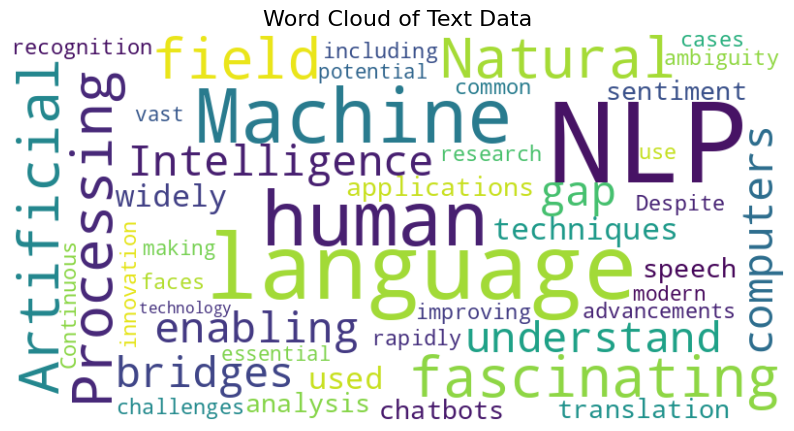

In [32]:
plt.figure(figsize=(10,9))
plt.imshow(wordcloud,interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Text Data",fontsize=16)
plt.show()